<h1 style="color:green;">Predicting Body Mass Categories from Height & Weight using K-Nearest Neighbors</h1>

<h3>Importing Required Library</h3>

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import joblib

<h3>Loading Data into Pandas DataFrame</h3>

In [82]:
bmi=pd.read_csv(r"C:\Users\Aashiya\OneDrive\Desktop\ML Bootcamp\Datasets\bmi.csv")

<h3>Displaying Shapes of the Dataset</h3>

In [83]:
print("Number of Dimensions : ",bmi.shape[0])
print("Number of Features : ",bmi.shape[1])

Number of Dimensions :  500
Number of Features :  4


<h3>Displaying Features of the Dataset</h3>

In [84]:
print("Features".center(50,'-'))
for col in bmi.columns:
    print(col)

---------------------Features---------------------
Gender
Height
Weight
Index


<h3>Displaying First 5 Records</h3>

In [85]:
bmi.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


<h3>Displaying Last 5 Records</h3>

In [86]:
bmi.tail()

,Gender,Height,Weight,Index
495,Female,150,153,5
496,Female,184,121,4
497,Female,141,136,5
498,Male,150,95,5
499,Male,173,131,5


<h3>Displaying Summerized Information</h3>

In [87]:
bmi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


<h3>Displaying Statistics of the Dataset</h3>

In [88]:
bmi.describe()

,Height,Weight,Index
count,500.000000,500.000000,500.000000
mean,169.944000,106.000000,3.748000
std,16.375261,32.382607,1.355053
min,140.000000,50.000000,0.000000
25%,156.000000,80.000000,3.000000
50%,170.500000,106.000000,4.000000
75%,184.000000,136.000000,5.000000
max,199.000000,160.000000,5.000000


<h3>Mapping Index Values to Human-Readable Health Categories</h3>

In [89]:
label_mapping = {
    0: 'Extremely Weak',
    1: 'Weak/Underweight',
    2: 'Normal/Healthy',
    3: 'Overweight',
    4: 'Obesity',
    5: 'Extreme Obesity'
}

bmi['Health_Status'] = bmi['Index'].map(label_mapping)

bmi.head()

,Gender,Height,Weight,Index,Health_Status
0,Male,174,96,4,Obesity
1,Male,189,87,2,Normal/Healthy
2,Female,185,110,4,Obesity
3,Female,195,104,3,Overweight
4,Male,149,61,3,Overweight


<h3>Detecting Duplicate from Dataset</h3>

In [90]:
print("Total Dupliacte Records : ",bmi.duplicated().sum())

Total Dupliacte Records :  11


<h3>Removing Duplicates from Dataset</h3>

In [91]:
bmi.drop_duplicates(inplace=True)
print("Total Dupliacte Records after Removing Duplicate : ",bmi.duplicated().sum())

Total Dupliacte Records after Removing Duplicate :  0


<h3>Detecting Missing Values in Dataset</h3>

In [92]:
print("Features        Total Missing Value")
print("-----------------------------------")
bmi.isnull().sum()

Features        Total Missing Value
-----------------------------------


Gender           0
Height           0
Weight           0
Index            0
Health_Status    0
dtype: int64

<h3>Detecting Outliear by Data Visualization</h3>

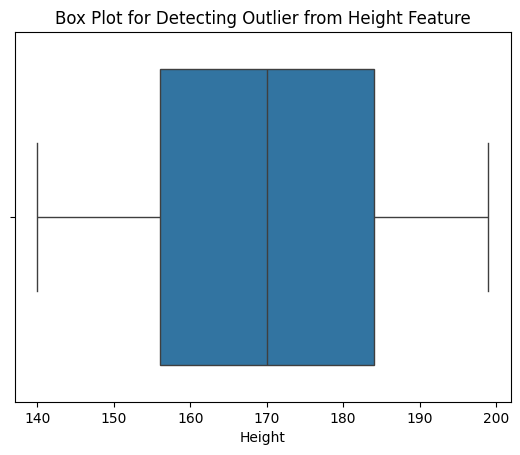

In [93]:
sb.boxplot(x=bmi.Height)
plt.title("Box Plot for Detecting Outlier from Height Feature")
plt.show()

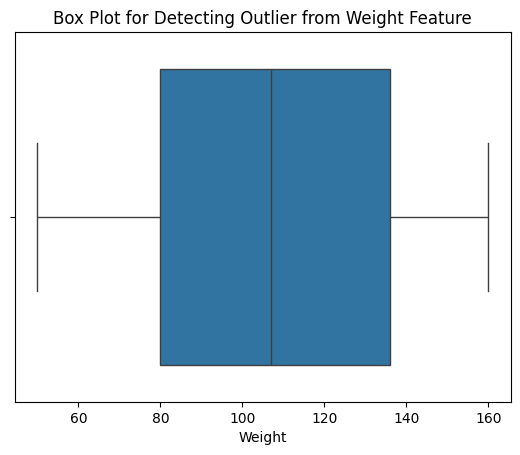

In [94]:
sb.boxplot(x=bmi.Weight)
plt.title("Box Plot for Detecting Outlier from Weight Feature")
plt.show()

<h3>Splitting Data into Dependent and Independent Variable</h3>

In [95]:
x=pd.DataFrame(bmi.iloc[:,1:3].values)
y=pd.DataFrame(bmi.iloc[:,3].values)

<h3>Splitting Data into Training and Testing Variable</h3>

In [96]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y)

<h3>Creating the Model</h3>

In [97]:
bmi_model=KNeighborsClassifier(n_neighbors=7)

<h3>Training the Model</h3>

In [98]:
bmi_model.fit(xtrain,ytrain)

C:\Users\Aashiya\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](6,)","[0,1,2,3,4,5]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


<h3>Saving the Model</h3>

In [99]:
joblib.dump(bmi_model, 'bmi_model.joblib')
print("✅ Model successfully saved as 'bmi_model.joblib'!")

✅ Model successfully saved as 'bmi_model.joblib'!


<h3>Testing the Model</h3>

In [100]:
result=['Extremely Weak', 'Weak', 'Normal', 'Overweight', 'Obesity', 'Extreme Obesity']
h=int(input("Enter Height In Cm : "))
w=float(input("Enter Weight : "))

ypred=bmi_model.predict([[h,w]])
print("Predicted category : ",result[ypred[0]])

Enter Height In Cm :  180
Enter Weight :  55


Predicted category :  Weak


In [101]:
ypred=bmi_model.predict(xtest)
print("Acccuracy Score : ",accuracy_score(ytest,ypred)*100)

Acccuracy Score :  84.5528455284553
